<a href="https://colab.research.google.com/github/GUNAPILLCO/neural_profit/blob/main/2_obtencion_preparacion_exploracion_datos/2_5_correlacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2.5. Correlación

## 0. Clonado de repositorio, importación de librerías y carga del dataset

### Clonado de repositorio e importación de librerías

In [115]:
#Clonamos el repo
#LINK DE REPOSITORIO: https://github.com/GUNAPILLCO/neural_profit

!git clone https://github.com/GUNAPILLCO/neural_profit.git

fatal: destination path 'neural_profit' already exists and is not an empty directory.


In [116]:
import sys

#Instalación de librería pandas_market_calendars
#!{sys.executable} -m pip install -q pandas_market_calendars
#print("Librería instalada: pandas_market_calendars")

!{sys.executable} -m pip install -q ta
print("Librería instalada: technical-analysis")

# Utilidades generales
from datetime import datetime, timedelta
import os
import glob
import requests
import warnings
warnings.filterwarnings('ignore')

# Manejo y procesamiento de datos
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt
# Calendario de mercados
#import pandas_market_calendars as mcal
import ta
from ta.momentum import StochasticOscillator, ROCIndicator
from ta.volatility import BollingerBands, AverageTrueRange

from scipy.stats import spearmanr

Librería instalada: technical-analysis


### Carga del dataset mnq_intraday_data

In [117]:
def load_df():
    """
    Función para cargar un archivo Parquet desde el repositorio clonado
    """
    # Definir la URL del archivo Parquet en GitHub
    df_path = '/content/neural_profit/2_obtencion_preparacion_exploracion_datos/mnq_intraday_data.parquet'

    # Leer el archivo Parquet y cargarlo en un DataFrame
    df = pd.read_parquet(df_path)

    # Asegurar que el índice esté en formato datetime
    df.index = pd.to_datetime(df.index)

    # Crear una nueva columna 'date' con la fecha extraída del índice
    df['date'] = df.index.date

    # Reordenar columnas: 'date', 'time_str', y luego el resto
    cols = ['date'] + [col for col in df.columns if col not in ['date']]

    df = df[cols]

    return df

In [118]:
mnq_intraday = load_df()

## 1. Definición de Target

Recordemos que nuestro target es el retorno de la variables 'close' y lo evaluaremos en tres ventanas de tiempo: 5, 15 y 30 minutos.

In [119]:
def add_targets (df):
  df['target_return_30'] = df.groupby('date')['close'].transform(lambda x: np.log(x.shift(-30)) - np.log(x))
  return df

In [120]:
mnq_intraday = add_targets(mnq_intraday)

## 2. Agregar indicadores técnicos

In [121]:

'''
def indicadores_tecnicos(df=mnq_intraday, target='target_return_30' ):
  indicadores_tecnicos_lista = ['rsi_14', 'rsi_7', 'macd', 'bb_percent_20_20', 'bb_percent_30_20', 'atr_norm']

  def aplicar_por_dia (grupo):
        grupo = grupo.copy()
        #RSI 14 y RSI 7
        grupo['rsi_14'] = ta.momentum.RSIIndicator(grupo[target], window=14).rsi()
        grupo['rsi_7'] = ta.momentum.RSIIndicator(grupo[target], window=7).rsi()

        #MACD
        grupo['macd'] = ta.trend.MACD(grupo[target]).macd_diff()

        #BB PERCENT
        grupo['bb_percent_20_20'] = BollingerBands(grupo[target], window=20, window_dev=2).bollinger_pband()
        grupo['bb_percent_30_20'] = BollingerBands(grupo[target], window=30, window_dev=2).bollinger_pband()

        #ATR Normalizado
        atr = AverageTrueRange(high=grupo['high'], low=grupo['low'], close=grupo[target], window=14)
        grupo['atr'] = atr.average_true_range()
        grupo['atr_norm'] = grupo['atr'] / grupo[target]
        #atr = AverageTrueRange(high=grupo['high'], low=grupo['low'], close=grupo[target], window=14)
        #grupo['atr_norm'] = atr.average_true_range() / grupo[target]

        return grupo

  df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)
  return df, indicadores_tecnicos_lista
  '''

"\ndef indicadores_tecnicos(df=mnq_intraday, target='target_return_30' ):\n  indicadores_tecnicos_lista = ['rsi_14', 'rsi_7', 'macd', 'bb_percent_20_20', 'bb_percent_30_20', 'atr_norm']\n\n  def aplicar_por_dia (grupo):\n        grupo = grupo.copy()\n        #RSI 14 y RSI 7\n        grupo['rsi_14'] = ta.momentum.RSIIndicator(grupo[target], window=14).rsi()\n        grupo['rsi_7'] = ta.momentum.RSIIndicator(grupo[target], window=7).rsi()\n\n        #MACD\n        grupo['macd'] = ta.trend.MACD(grupo[target]).macd_diff()\n\n        #BB PERCENT\n        grupo['bb_percent_20_20'] = BollingerBands(grupo[target], window=20, window_dev=2).bollinger_pband()\n        grupo['bb_percent_30_20'] = BollingerBands(grupo[target], window=30, window_dev=2).bollinger_pband()\n\n        #ATR Normalizado\n        atr = AverageTrueRange(high=grupo['high'], low=grupo['low'], close=grupo[target], window=14)\n        grupo['atr'] = atr.average_true_range()\n        grupo['atr_norm'] = grupo['atr'] / grupo[targ

In [122]:
def add_indicators(df=mnq_intraday, target='close' ):

  indicators_list= [
    'momentum_3',
    'momentum_10',
    'roc_5',
    'roc_20',
    'rsi_3',
    'rsi_7',
    'rsi_14',
    'stoch_k_20',
    'bb_percent_20_15',
    'bb_percent_30_20',
    'price_ema30',
    'atr_norm']


  def aplicar_por_dia (grupo):
        grupo = grupo.copy()

        # MOMENTUM y VELOCIDAD
        grupo['momentum_3'] = grupo[target].pct_change(3)
        grupo['momentum_10'] = grupo[target].pct_change(10)
        grupo['roc_5'] = ROCIndicator(close=grupo[target], window=5).roc()
        grupo['roc_20'] = ROCIndicator(close=grupo[target], window=20).roc()

        # SOBRECOMPRA / SOBREVENTA (RSI)
        grupo['rsi_3'] = ta.momentum.RSIIndicator(grupo[target], window=3).rsi()
        grupo['rsi_7'] = ta.momentum.RSIIndicator(grupo[target], window=7).rsi()
        grupo['rsi_14'] = ta.momentum.RSIIndicator(grupo[target], window=14).rsi()

        stoch_20 = StochasticOscillator(high=grupo['high'], low=grupo['low'], close=grupo[target], window=20, smooth_window=3)
        grupo['stoch_k_20'] = stoch_20.stoch()

        # BOLLINGER BANDS
        grupo['bb_percent_20_15'] = BollingerBands(grupo[target], window=20, window_dev=1.5).bollinger_pband()
        grupo['bb_percent_30_20'] = BollingerBands(grupo[target], window=30, window_dev=2).bollinger_pband()

        # TENDENCIA RELATIVA
        grupo['price_ema30'] = grupo[target] / grupo[target].ewm(span=30).mean() - 1

        # VOLATILIDAD
        atr = AverageTrueRange(high=grupo['high'], low=grupo['low'], close=grupo[target], window=14)
        grupo['atr'] = atr.average_true_range()
        grupo['atr_norm'] = grupo['atr'] / grupo[target]
        grupo.drop(columns=['atr'], inplace=True)  #Elimino columna 'atr'
        return grupo

  df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)
  return df, indicators_list

In [123]:
mnq_intraday, factores = add_indicators()

In [124]:
mnq_intraday

,date,open,high,low,close,volume,target_return_30,momentum_3,momentum_10,roc_5,roc_20,rsi_3,rsi_7,rsi_14,stoch_k_20,bb_percent_20_15,bb_percent_30_20,price_ema30,atr_norm
datetime,,,,,,,,,,,,,,,,,,,
2019-12-23 08:00:00-05:00,2019-12-23,8734.00,8734.25,8733.75,8733.75,31,0.000372,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000
2019-12-23 08:01:00-05:00,2019-12-23,8734.00,8734.25,8733.75,8734.00,16,0.000286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.383501e-05,0.000000
2019-12-23 08:02:00-05:00,2019-12-23,8734.00,8734.00,8733.25,8733.25,23,0.000315,NaN,NaN,NaN,NaN,18.181818,NaN,NaN,NaN,NaN,NaN,-4.640816e-05,0.000000
2019-12-23 08:03:00-05:00,2019-12-23,8734.25,8734.50,8734.00,8734.00,23,0.000315,0.000029,NaN,NaN,NaN,63.265306,NaN,NaN,NaN,NaN,NaN,2.859176e-05,0.000000
2019-12-23 08:04:00-05:00,2019-12-23,8734.00,8734.00,8733.50,8733.75,12,0.000458,-0.000029,NaN,NaN,NaN,49.600000,NaN,NaN,NaN,NaN,NaN,-2.535945e-08,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-13 15:56:00-04:00,2025-06-13,21624.50,21635.00,21613.50,21617.50,3251,NaN,-0.000231,0.000278,-0.094741,-0.073959,33.780079,39.066557,42.096236,22.413793,0.128027,0.206181,-8.844700e-04,0.000871
2025-06-13 15:57:00-04:00,2025-06-13,21616.50,21635.25,21615.75,21623.75,2201,NaN,0.000382,0.000243,-0.047379,-0.156988,52.504050,45.637235,45.107585,31.034483,0.266734,0.306572,-5.572032e-04,0.000873
2025-06-13 15:58:00-04:00,2025-06-13,21623.25,21632.75,21616.50,21621.75,1859,NaN,-0.000127,0.000104,-0.003469,-0.219205,46.229664,43.871077,44.313396,28.373702,0.255214,0.280376,-6.077556e-04,0.000864


In [125]:
factores

['momentum_3',
 'momentum_10',
 'roc_5',
 'roc_20',
 'rsi_3',
 'rsi_7',
 'rsi_14',
 'stoch_k_20',
 'bb_percent_20_15',
 'bb_percent_30_20',
 'price_ema30',
 'atr_norm']

## 3. Añadir alpha factors de hipotesis

In [126]:
alpha_factors_lista = []

### 3.1. Hipotesis 1

In [127]:
def add_reversion_momentum_factor(df: pd.DataFrame,
                          price_col: str = 'close',
                          date_col: str = 'date',
                          window: int = 30) -> pd.DataFrame:
    """
    Agrega una columna 'reversion_media_factor' que es el 'momentum_rev_z_30' al DataFrame, representando el alpha factor
    de reversión a la media basado en el z-score invertido de log-retornos a N minutos.

    Parámetros:
    - df: DataFrame de entrada con columnas de precios y fechas
    - price_col: nombre de la columna de precios (default='close')
    - date_col: nombre de la columna de fecha o jornada (default='date')
    - window: cantidad de minutos para calcular el momentum (default=30)

    Retorna:
    - DataFrame con la columna 'reversion_media_factor' añadida
    """
    df = df.copy()

    def calc_reversal(x):
        m = np.log(x) - np.log(x.shift(window))
        return -(m - m.mean()) / m.std()

    af_1 = 'reversal_momentum_factor'
    df[af_1] = df.groupby(date_col)[price_col].transform(calc_reversal)
    #df = df.dropna(subset=['momentum_rev_z_30'])

    return df, af_1

In [128]:
mnq_intraday, alpha_factor_1 = add_reversion_momentum_factor(mnq_intraday)

In [129]:
factores.append(alpha_factor_1)

### 3.2. Hipotesis 2

In [130]:
def add_reversal_media_factor(df: pd.DataFrame, window: int = 30, price_col: str = 'close') -> pd.DataFrame:
    """
    Agrega al DataFrame un alpha factor basado en la hipótesis 2 (reversión a la media),
    llamado 'reversal_score_{window}', calculado como z-score normalizado por jornada.

    No guarda columnas intermedias.

    Parámetros:
    - df: DataFrame con columnas 'date' y una columna de precios (por defecto 'close')
    - window: Ventana para el cálculo del z-score (en minutos)
    - price_col: Nombre de la columna de precios

    Retorna:
    - El DataFrame original con una nueva columna 'reversal_score_{window}'
    """
    z_col = f'_tmp_z_{window}'
    reversal_col = f'reversal_media_factor'

    # Calcular z-score por jornada
    df[z_col] = df.groupby('date')[price_col].transform(
        lambda x: (x - x.rolling(window=window, min_periods=1).mean()) /
                  x.rolling(window=window, min_periods=1).std()
    )

    # Normalizar el z-score por jornada
    df[reversal_col] = df.groupby('date')[z_col].transform(
        lambda x: (x - x.mean()) / x.std()
    )

    # Eliminar columna temporal
    df.drop(columns=[z_col], inplace=True)

    return df, reversal_col

In [131]:
mnq_intraday, alpha_factor_2 = add_reversal_media_factor(mnq_intraday)

In [132]:
factores.append(alpha_factor_2)

### 3.3. Hipotesis 3

In [133]:
def add_reversion_vol_momentum_factor(df: pd.DataFrame,
                                      price_col: str = 'close',
                                      volume_col: str = 'volume',
                                      date_col: str = 'date',
                                      window: int = 30) -> pd.DataFrame:
    """
    Agrega una columna 'reversion_vol_momentum_factor' al DataFrame,
    que representa un alpha factor de reversión basado en:
    - Momentum a N minutos
    - Relación volumen actual / volumen promedio N
    - Z-score del factor por jornada
    - Inversión de signo para capturar reversión

    Parámetros:
    - df: DataFrame de entrada con columnas de precios, volumen y fechas
    - price_col: nombre de la columna de precios (default='close')
    - volume_col: nombre de la columna de volumen (default='volume')
    - date_col: nombre de la columna de fecha o jornada (default='date')
    - window: ventana en minutos para calcular momentum y volumen promedio (default=30)

    Retorna:
    - DataFrame con la columna 'reversion_vol_momentum_factor' añadida
    """
    df = df.copy()

    # 1. Calcular el momentum
    df['momentum'] = df.groupby(date_col)[price_col].transform(
        lambda x: np.log(x) - np.log(x.shift(window))
    )

    # 2. Calcular volumen promedio intradía (rolling por jornada)
    df['vol_avg'] = df.groupby(date_col)[volume_col].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )

    # 3. Relación volumen actual / volumen promedio
    df['vol_ratio'] = df[volume_col] / df['vol_avg']

    # 4. Alpha factor crudo: momentum × vol_ratio
    df['mom_vol'] = df['momentum'] * df['vol_ratio']

    # 5. Normalización diaria y reversión
    af_name = 'reversion_vol_momentum_factor'
    df[af_name] = df.groupby(date_col)['mom_vol'].transform(
        lambda x: -(x - x.mean()) / x.std()
    )

    # 6. Limpieza opcional de columnas intermedias
    df.drop(columns=['momentum', 'vol_avg', 'vol_ratio', 'mom_vol'], inplace=True)

    return df, af_name

In [134]:
mnq_intraday, alpha_factor_3 = add_reversion_vol_momentum_factor(mnq_intraday)

In [135]:
factores.append(alpha_factor_3)

### 4. Hipotesis 4

In [136]:
def add_opening_exhaustion_factor30(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Calcular métricas de apertura por jornada
    opening_start = "08:00:00"
    opening_end = "09:30:00"

    def get_opening_metrics(x):
        high = x.between_time(opening_start, opening_end)['high'].max()
        low = x.between_time(opening_start, opening_end)['low'].min()
        opening_range = high - low
        midpoint = (high + low) / 2
        return pd.Series({'range': opening_range, 'midpoint': midpoint})

    opening_df = df.groupby('date').apply(get_opening_metrics)

    # Calcular factor raw (solo después de 09:30)
    df = df.join(opening_df.rename(columns={'range': 'opening_range', 'midpoint': 'opening_midpoint'}), on='date')
    df['after_opening'] = df.index >= df.index.normalize() + pd.Timedelta("09:30:00")

    df['factor_raw'] = (
        (df['close'] - df['opening_midpoint']) / df['opening_range']
    ).where(df['after_opening'])

    # Calcular factor30 (z-score del raw, por día)
    af_name = 'factor30'
    df[af_name] = df.groupby('date')['factor_raw'].transform(
        lambda x: (x - x.mean()) / x.std()
    )

    # Limpiar columnas intermedias
    df = df.drop(columns=[
        'opening_range', 'opening_midpoint', 'after_opening', 'factor_raw'
    ])

    return df, af_name

In [137]:
mnq_intraday, alpha_factor_4 = add_opening_exhaustion_factor30(mnq_intraday)

In [138]:
factores.append(alpha_factor_4)

indicadores_te

In [139]:
factores

['momentum_3',
 'momentum_10',
 'roc_5',
 'roc_20',
 'rsi_3',
 'rsi_7',
 'rsi_14',
 'stoch_k_20',
 'bb_percent_20_15',
 'bb_percent_30_20',
 'price_ema30',
 'atr_norm',
 'reversal_momentum_factor',
 'reversal_media_factor',
 'reversion_vol_momentum_factor',
 'factor30']

## IC

In [156]:
def calcular_IC(df: pd.DataFrame, target: str, factors: list[str]):
    grouped = df.groupby('date')

    #print(f"IC promedio por factor (diario) sobre el {target}:\n")

    resultados = []

    for factor in factors:
        daily_ics = []

        for date, group in grouped:
            df_valid = group[[factor, target]].dropna()
            if len(df_valid) >= 20:
                ic = spearmanr(df_valid[factor], df_valid[target]).correlation
                if np.isfinite(ic):
                    daily_ics.append(ic)

        if daily_ics:
            mean_ic = np.mean(daily_ics)
            std_ic = np.std(daily_ics)
            dias_validos = len(daily_ics)
            #print(f"{factor:15}: IC medio = {mean_ic:.4f} | std = {std_ic:.4f} | días válidos = {dias_validos}")
            resultados.append({
                'factor': factor,
                'ic_mean': mean_ic,
                'ic_std': std_ic,
                #'dias_validos': dias_validos
            })
        else:
            print(f"{factor:15}: sin días válidos para cálculo")

    return pd.DataFrame(resultados)

In [157]:
df_factores = calcular_IC(mnq_intraday, 'target_return_30', factores)

In [158]:
# Calcular la nueva columna IC_score
df_factores["ic_score"] = df_factores["ic_mean"].abs() / df_factores["ic_std"]

# Ordenar por IC_score de mayor a menor
IC_factores = df_factores.sort_values(by="ic_score", ascending=False).reset_index(drop=True)

In [159]:
df_factores

,factor,ic_mean,ic_std,ic_score
0,momentum_3,-0.032888,0.073411,0.448001
1,momentum_10,-0.053240,0.129744,0.410347
2,roc_5,-0.040213,0.093976,0.427903
3,roc_20,-0.072436,0.171965,0.421228
4,rsi_3,-0.043152,0.095357,0.452531
5,rsi_7,-0.062888,0.137946,0.455891
6,rsi_14,-0.088180,0.172203,0.512072
7,stoch_k_20,-0.070241,0.147213,0.477135
8,bb_percent_20_15,-0.063539,0.141046,0.450485
9,bb_percent_30_20,-0.078302,0.165005,0.474544


## CORRELACIÓN


In [160]:
def corr_target (df):

  # Calcular la correlación de Spearman con el target
  correlaciones_target = df[factores + ['target_return_30']].corr(method='spearman')['target_return_30']

  # Eliminar la correlación del target consigo mismo
  correlaciones_target = correlaciones_target.drop('target_return_30')

  # Ordenar por el valor absoluto de la correlación
  tabla_correlaciones = correlaciones_target.abs().sort_values(ascending=False)

  # Crear tabla final con el signo original de la correlación
  corr_target = correlaciones_target.loc[tabla_correlaciones.index].reset_index()
  corr_target.columns = ['factor', 'corr_target']

  # ----- MAPA DE CALOR -----
  # Subconjunto de variables + target para visualización
  subset_corr = df[factores + ['target_return_30']].corr(method='spearman')

  plt.figure(figsize=(12, 8))
  sns.heatmap(subset_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
  plt.title("Mapa de Calor de Correlación (Spearman) con target_return_30")
  plt.show()

  return corr_target

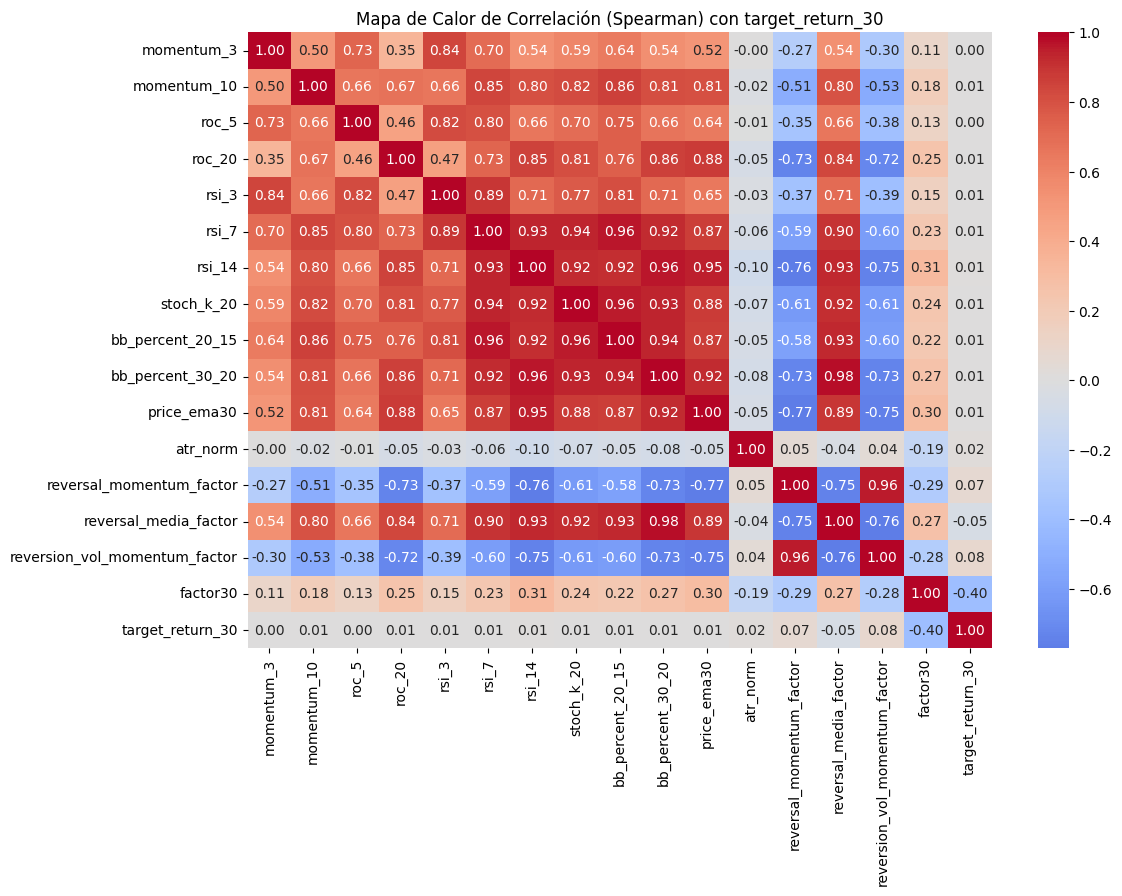

In [161]:
corr = corr_target(mnq_intraday)

Para esto, el mapa de calor de correlación es una herramienta excelente, ya que te permite:

- Detectar redundancias: Si dos factores están altamente correlacionados (por ejemplo, > 0.9 o < -0.9), puede que estén aportando información similar.

- Identificar relaciones: Puedes descubrir patrones de comportamiento entre factores técnicos y alpha factors.

- Reducir dimensionalidad: Si hay grupos de factores similares, podrías considerar usar solo uno de cada grupo o aplicar PCA.

In [162]:
corr

,factor,corr_target
0,factor30,-0.402906
1,reversion_vol_momentum_factor,0.081307
2,reversal_momentum_factor,0.072542
3,reversal_media_factor,-0.047148
4,atr_norm,0.022041
5,rsi_14,0.011183
6,price_ema30,0.010853
7,rsi_7,0.008854
8,roc_20,0.007264
9,momentum_10,0.006688


In [163]:
def corr_factor_factor (mnq_intraday, corr):
  # Paso 1: excluir columnas no técnicas
  columnas_base = ["date", "open", "high", "low", "close", "volume", "target_return_30"]
  df_tecnicos = mnq_intraday.drop(columns=columnas_base, errors='ignore')

  # Paso 2: calcular la matriz de correlación
  matriz_corr = df_tecnicos.corr()

  # Paso 3: para cada factor en IC_indicadores, encontrar los 5 más correlacionados
  top5_factores = []
  top5_valores = []

  for factor in corr['factor']:
      if factor in matriz_corr.columns:
          corrs = matriz_corr[factor].drop(labels=[factor])  # eliminar autocorrelación
          top5 = corrs.abs().sort_values(ascending=False).head(5)
          factores = top5.index.tolist()
          valores = [matriz_corr.loc[factor, f] for f in factores]
      else:
          factores = [None, None, None]
          valores = [None, None, None]

      top5_factores.append(factores)
      top5_valores.append(valores)

  # Paso 4: añadir al DataFrame original como columnas separadas
  corr["corr_ind_1"] = [f[0] for f in top5_factores]
  corr["corr_value_1"] = [v[0] for v in top5_valores]

  corr["corr_ind_2"] = [f[1] for f in top5_factores]
  corr["corr_value_2"] = [v[1] for v in top5_valores]

  corr["corr_ind_3"] = [f[2] for f in top5_factores]
  corr["corr_value_3"] = [v[2] for v in top5_valores]

  corr["corr_ind_4"] = [f[3] for f in top5_factores]
  corr["corr_value_4"] = [v[3] for v in top5_valores]

  corr["corr_ind_5"] = [f[4] for f in top5_factores]
  corr["corr_value_5"] = [v[4] for v in top5_valores]

  return corr

In [164]:
corr = corr_factor_factor(mnq_intraday, corr)

In [165]:
corr

,factor,corr_target,corr_ind_1,corr_value_1,corr_ind_2,corr_value_2,corr_ind_3,corr_value_3,corr_ind_4,corr_value_4,corr_ind_5,corr_value_5
0,factor30,-0.402906,rsi_14,0.314491,reversal_momentum_factor,-0.312990,price_ema30,0.277002,reversal_media_factor,0.271451,reversion_vol_momentum_factor,-0.267432
1,reversion_vol_momentum_factor,0.081307,reversal_momentum_factor,0.832473,rsi_14,-0.723225,reversal_media_factor,-0.697312,price_ema30,-0.686324,bb_percent_30_20,-0.681477
2,reversal_momentum_factor,0.072542,reversion_vol_momentum_factor,0.832473,rsi_14,-0.756146,price_ema30,-0.714306,reversal_media_factor,-0.698317,bb_percent_30_20,-0.682492
3,reversal_media_factor,-0.047148,bb_percent_30_20,0.977858,bb_percent_20_15,0.927673,stoch_k_20,0.902839,rsi_14,0.899321,rsi_7,0.892590
4,atr_norm,0.022041,factor30,-0.125467,rsi_14,-0.073454,stoch_k_20,-0.061786,bb_percent_30_20,-0.052946,reversal_momentum_factor,0.044765
5,rsi_14,0.011183,rsi_7,0.936097,bb_percent_30_20,0.935810,reversal_media_factor,0.899321,stoch_k_20,0.898714,bb_percent_20_15,0.889642
6,price_ema30,0.010853,roc_20,0.901228,momentum_10,0.847844,rsi_14,0.816439,bb_percent_30_20,0.764602,rsi_7,0.745779
7,rsi_7,0.008854,bb_percent_20_15,0.945422,rsi_14,0.936097,stoch_k_20,0.921289,bb_percent_30_20,0.911995,rsi_3,0.893601
8,roc_20,0.007264,price_ema30,0.901228,rsi_14,0.739852,momentum_10,0.709208,bb_percent_30_20,0.695420,reversal_momentum_factor,-0.681863
9,momentum_10,0.006688,price_ema30,0.847844,rsi_7,0.721173,roc_20,0.709208,roc_5,0.707036,rsi_14,0.698309


In [166]:
IC_factores

,factor,ic_mean,ic_std,ic_score
0,factor30,-0.463214,0.188685,2.454954
1,rsi_14,-0.088180,0.172203,0.512072
2,price_ema30,-0.087274,0.176637,0.494089
3,stoch_k_20,-0.070241,0.147213,0.477135
4,bb_percent_30_20,-0.078302,0.165005,0.474544
5,reversal_momentum_factor,0.090506,0.194918,0.464330
6,rsi_7,-0.062888,0.137946,0.455891
7,reversal_media_factor,-0.073525,0.161838,0.454314
8,rsi_3,-0.043152,0.095357,0.452531
9,bb_percent_20_15,-0.063539,0.141046,0.450485


In [175]:
df_factores= IC_factores.merge(corr, on='factor', how='inner')

In [176]:
df_factores

,factor,ic_mean,ic_std,ic_score,corr_target,corr_ind_1,corr_value_1,corr_ind_2,corr_value_2,corr_ind_3,corr_value_3,corr_ind_4,corr_value_4,corr_ind_5,corr_value_5
0,factor30,-0.463214,0.188685,2.454954,-0.402906,rsi_14,0.314491,reversal_momentum_factor,-0.312990,price_ema30,0.277002,reversal_media_factor,0.271451,reversion_vol_momentum_factor,-0.267432
1,rsi_14,-0.088180,0.172203,0.512072,0.011183,rsi_7,0.936097,bb_percent_30_20,0.935810,reversal_media_factor,0.899321,stoch_k_20,0.898714,bb_percent_20_15,0.889642
2,price_ema30,-0.087274,0.176637,0.494089,0.010853,roc_20,0.901228,momentum_10,0.847844,rsi_14,0.816439,bb_percent_30_20,0.764602,rsi_7,0.745779
3,stoch_k_20,-0.070241,0.147213,0.477135,0.005322,bb_percent_20_15,0.948167,bb_percent_30_20,0.922871,rsi_7,0.921289,reversal_media_factor,0.902839,rsi_14,0.898714
4,bb_percent_30_20,-0.078302,0.165005,0.474544,0.005116,reversal_media_factor,0.977858,bb_percent_20_15,0.941975,rsi_14,0.935810,stoch_k_20,0.922871,rsi_7,0.911995
5,reversal_momentum_factor,0.090506,0.194918,0.464330,0.072542,reversion_vol_momentum_factor,0.832473,rsi_14,-0.756146,price_ema30,-0.714306,reversal_media_factor,-0.698317,bb_percent_30_20,-0.682492
6,rsi_7,-0.062888,0.137946,0.455891,0.008854,bb_percent_20_15,0.945422,rsi_14,0.936097,stoch_k_20,0.921289,bb_percent_30_20,0.911995,rsi_3,0.893601
7,reversal_media_factor,-0.073525,0.161838,0.454314,-0.047148,bb_percent_30_20,0.977858,bb_percent_20_15,0.927673,stoch_k_20,0.902839,rsi_14,0.899321,rsi_7,0.892590
8,rsi_3,-0.043152,0.095357,0.452531,0.005018,rsi_7,0.893601,bb_percent_20_15,0.816016,stoch_k_20,0.760176,rsi_14,0.722859,bb_percent_30_20,0.720733
9,bb_percent_20_15,-0.063539,0.141046,0.450485,0.005533,stoch_k_20,0.948167,rsi_7,0.945422,bb_percent_30_20,0.941975,reversal_media_factor,0.927673,rsi_14,0.889642


In [169]:
mnq_intraday

,date,open,high,low,close,volume,target_return_30,momentum_3,momentum_10,roc_5,...,rsi_14,stoch_k_20,bb_percent_20_15,bb_percent_30_20,price_ema30,atr_norm,reversal_momentum_factor,reversal_media_factor,reversion_vol_momentum_factor,factor30
datetime,,,,,,,,,,,,,,,,,,,,,
2019-12-23 08:00:00-05:00,2019-12-23,8734.00,8734.25,8733.75,8733.75,31,0.000372,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000e+00,0.000000,NaN,NaN,NaN,NaN
2019-12-23 08:01:00-05:00,2019-12-23,8734.00,8734.25,8733.75,8734.00,16,0.000286,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.383501e-05,0.000000,NaN,0.640953,NaN,NaN
2019-12-23 08:02:00-05:00,2019-12-23,8734.00,8734.00,8733.25,8733.25,23,0.000315,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-4.640816e-05,0.000000,NaN,-0.678763,NaN,NaN
2019-12-23 08:03:00-05:00,2019-12-23,8734.25,8734.50,8734.00,8734.00,23,0.000315,0.000029,NaN,NaN,...,NaN,NaN,NaN,NaN,2.859176e-05,0.000000,NaN,0.640953,NaN,NaN
2019-12-23 08:04:00-05:00,2019-12-23,8734.00,8734.00,8733.50,8733.75,12,0.000458,-0.000029,NaN,NaN,...,NaN,NaN,NaN,NaN,-2.535945e-08,0.000000,NaN,0.121999,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-13 15:56:00-04:00,2025-06-13,21624.50,21635.00,21613.50,21617.50,3251,NaN,-0.000231,0.000278,-0.094741,...,42.096236,22.413793,0.128027,0.206181,-8.844700e-04,0.000871,0.165914,-0.771226,0.164321,-1.771542
2025-06-13 15:57:00-04:00,2025-06-13,21616.50,21635.25,21615.75,21623.75,2201,NaN,0.000382,0.000243,-0.047379,...,45.107585,31.034483,0.266734,0.306572,-5.572032e-04,0.000873,0.048450,-0.484803,0.037936,-1.681710
2025-06-13 15:58:00-04:00,2025-06-13,21623.25,21632.75,21616.50,21621.75,1859,NaN,-0.000127,0.000104,-0.003469,...,44.313396,28.373702,0.255214,0.280376,-6.077556e-04,0.000864,0.043942,-0.559542,0.027141,-1.710456


# OTROS

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_y_analizar_ic_tecnicos(df: pd.DataFrame,
                                 factors: list[str],
                                 target: str,
                                 date_col: str = 'date',
                                 market_open: str = "08:00",
                                 ventana: int = 30) -> pd.DataFrame:
    """
    Calcula, grafica y analiza el IC por minuto intradía para una lista de indicadores técnicos.
    Además evalúa los bloques de mejor y peor IC promedio por factor.

    Parámetros:
    - df: DataFrame con datos intradía por minuto.
    - factors: Lista de columnas (indicadores técnicos) a evaluar.
    - target: Nombre de la columna target (e.g., 'target_return_30').
    - date_col: Nombre de la columna de fecha (por defecto 'date').
    - market_open: Hora de inicio del mercado (formato "HH:MM").
    - ventana: Tamaño de la ventana (en minutos) para promedio móvil.

    Retorna:
    - DataFrame con resumen de bloques de IC extremos por factor.
    """
    df = df.copy()
    df['minute_index'] = df.groupby(date_col).cumcount()

    # ---- Cálculo de IC por minuto ----
    def compute_ic_series(factor_col, target_col):
        grouped = df[[factor_col, target_col, 'minute_index']].dropna()
        return grouped.groupby('minute_index').apply(
            lambda x: x[factor_col].corr(x[target_col])
        )

    ic_series = {factor: compute_ic_series(factor, target) for factor in factors}

    # ---- Gráfico ----
    xticks = np.arange(0, 451, 30)
    start_time = pd.to_datetime(market_open)
    time_labels = [(start_time + pd.Timedelta(minutes=i)).strftime("%H:%M") for i in xticks]

    plt.figure(figsize=(15, 6))
    for factor, ic in ic_series.items():
        plt.plot(ic.index, ic, label=factor)

    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.title(f'IC por minuto del día - Target: {target}')
    plt.xlabel('Hora intradía')
    plt.ylabel('Information Coefficient (IC)')
    plt.xticks(ticks=xticks, labels=time_labels, rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ---- Análisis de bloques extremos ----
    minutos_inicio = int(pd.to_timedelta(market_open).total_seconds() / 60)

    def minuto_a_hora(minuto):
        total_min = minutos_inicio + minuto
        hora = pd.Timestamp("00:00") + pd.Timedelta(minutes=total_min)
        return hora.strftime("%H:%M")

    resultados = []
    for factor, serie in ic_series.items():
        serie = serie.dropna()
        promedio_ventana = serie.rolling(window=ventana, min_periods=ventana).mean()

        peor_inicio = promedio_ventana.idxmin()
        mejor_inicio = promedio_ventana.idxmax()
        peor_valor = promedio_ventana.loc[peor_inicio]
        mejor_valor = promedio_ventana.loc[mejor_inicio]

        rango_peor = f"{minuto_a_hora(peor_inicio)} - {minuto_a_hora(peor_inicio + ventana - 1)}"
        rango_mejor = f"{minuto_a_hora(mejor_inicio)} - {minuto_a_hora(mejor_inicio + ventana - 1)}"

        resultados.append({
            "factor": factor,
            #f"Promedio peor bloque {ventana}min": peor_valor,
            #f"Rango peor bloque {ventana}min": rango_peor,
            #f"Promedio mejor bloque {ventana}min": mejor_valor,
            #f"Rango mejor bloque {ventana}min": rango_mejor
            f"best_media":mejor_valor,
            f"best_hour": rango_mejor
        })

    return pd.DataFrame(resultados).sort_values(f"best_hour", ascending=False).reset_index(drop=True)

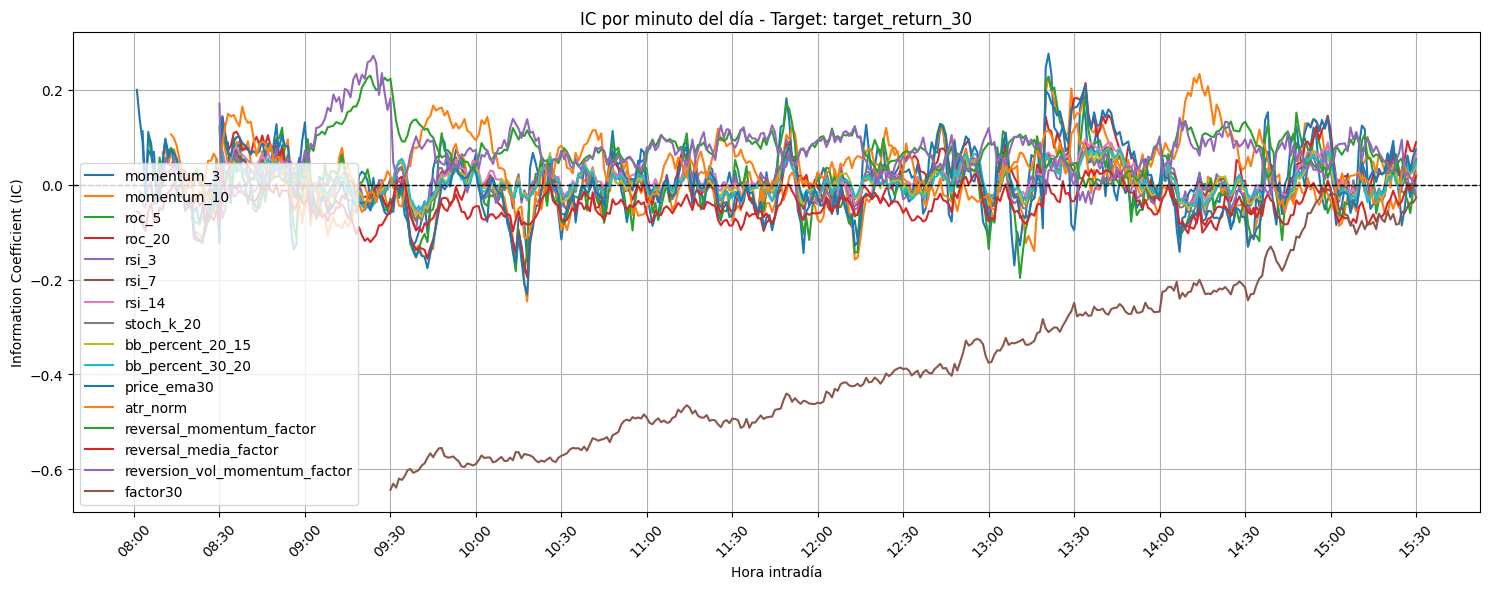

In [184]:
resumen_ic = plot_y_analizar_ic_tecnicos(
    df=mnq_intraday,                   # tu DataFrame intradía
    factors=factores,   # lista de columnas con alpha factors
    target='target_return_30',        # columna target
    date_col='date',                  # columna de fecha
    market_open="08:00:00",              # hora de apertura real si es 08:30
    ventana=60                        # tamaño de la ventana para análisis
)

In [185]:
resumen_ic

,factor,best_media,best_hour
0,factor30,-0.094046,15:30 - 16:29
1,atr_norm,0.085377,14:39 - 15:38
2,roc_20,0.068771,13:50 - 14:49
3,rsi_14,0.039964,13:50 - 14:49
4,bb_percent_20_15,0.027426,13:49 - 14:48
5,bb_percent_30_20,0.033326,13:49 - 14:48
6,price_ema30,0.075424,13:49 - 14:48
7,reversal_media_factor,-0.015553,13:49 - 14:48
8,rsi_3,0.018122,13:47 - 14:46
9,rsi_7,0.030689,13:47 - 14:46


In [186]:
df_factores= IC_factores.merge(resumen_ic, on='factor', how='inner')

In [188]:
df_factores=df_factores.merge(corr, on='factor', how='inner')

In [189]:
df_factores

,factor,ic_mean,ic_std,ic_score,best_media,best_hour,corr_target,corr_ind_1,corr_value_1,corr_ind_2,corr_value_2,corr_ind_3,corr_value_3,corr_ind_4,corr_value_4,corr_ind_5,corr_value_5
0,factor30,-0.463214,0.188685,2.454954,-0.094046,15:30 - 16:29,-0.402906,rsi_14,0.314491,reversal_momentum_factor,-0.312990,price_ema30,0.277002,reversal_media_factor,0.271451,reversion_vol_momentum_factor,-0.267432
1,rsi_14,-0.088180,0.172203,0.512072,0.039964,13:50 - 14:49,0.011183,rsi_7,0.936097,bb_percent_30_20,0.935810,reversal_media_factor,0.899321,stoch_k_20,0.898714,bb_percent_20_15,0.889642
2,price_ema30,-0.087274,0.176637,0.494089,0.075424,13:49 - 14:48,0.010853,roc_20,0.901228,momentum_10,0.847844,rsi_14,0.816439,bb_percent_30_20,0.764602,rsi_7,0.745779
3,stoch_k_20,-0.070241,0.147213,0.477135,0.023259,13:47 - 14:46,0.005322,bb_percent_20_15,0.948167,bb_percent_30_20,0.922871,rsi_7,0.921289,reversal_media_factor,0.902839,rsi_14,0.898714
4,bb_percent_30_20,-0.078302,0.165005,0.474544,0.033326,13:49 - 14:48,0.005116,reversal_media_factor,0.977858,bb_percent_20_15,0.941975,rsi_14,0.935810,stoch_k_20,0.922871,rsi_7,0.911995
5,reversal_momentum_factor,0.090506,0.194918,0.464330,0.121906,09:59 - 10:58,0.072542,reversion_vol_momentum_factor,0.832473,rsi_14,-0.756146,price_ema30,-0.714306,reversal_media_factor,-0.698317,bb_percent_30_20,-0.682492
6,rsi_7,-0.062888,0.137946,0.455891,0.030689,13:47 - 14:46,0.008854,bb_percent_20_15,0.945422,rsi_14,0.936097,stoch_k_20,0.921289,bb_percent_30_20,0.911995,rsi_3,0.893601
7,reversal_media_factor,-0.073525,0.161838,0.454314,-0.015553,13:49 - 14:48,-0.047148,bb_percent_30_20,0.977858,bb_percent_20_15,0.927673,stoch_k_20,0.902839,rsi_14,0.899321,rsi_7,0.892590
8,rsi_3,-0.043152,0.095357,0.452531,0.018122,13:47 - 14:46,0.005018,rsi_7,0.893601,bb_percent_20_15,0.816016,stoch_k_20,0.760176,rsi_14,0.722859,bb_percent_30_20,0.720733
9,bb_percent_20_15,-0.063539,0.141046,0.450485,0.027426,13:49 - 14:48,0.005533,stoch_k_20,0.948167,rsi_7,0.945422,bb_percent_30_20,0.941975,reversal_media_factor,0.927673,rsi_14,0.889642


In [191]:
mnq_model = mnq_intraday.copy()

In [193]:
mnq_model = mnq_model.dropna()

In [194]:
mnq_model

,date,open,high,low,close,volume,target_return_30,momentum_3,momentum_10,roc_5,...,rsi_14,stoch_k_20,bb_percent_20_15,bb_percent_30_20,price_ema30,atr_norm,reversal_momentum_factor,reversal_media_factor,reversion_vol_momentum_factor,factor30
datetime,,,,,,,,,,,,,,,,,,,,,
2019-12-23 09:30:00-05:00,2019-12-23,8733.75,8734.50,8731.25,8733.25,214,-0.000831,0.000143,0.000315,0.014315,...,49.006500,50.000000,0.739224,0.441651,-0.000051,0.000197,0.781812,-0.046414,0.877892,1.092168
2019-12-23 09:31:00-05:00,2019-12-23,8733.50,8733.50,8728.25,8729.50,1443,-0.000200,-0.000315,-0.000372,-0.020043,...,37.682151,15.625000,-0.088857,0.134612,-0.000449,0.000226,1.885030,-0.932620,9.871061,0.043107
2019-12-23 09:32:00-05:00,2019-12-23,8730.00,8730.50,8722.75,8726.00,1347,0.000029,-0.000945,-0.000601,-0.068713,...,30.579621,27.083333,-0.567670,-0.098581,-0.000795,0.000273,2.743548,-1.605686,9.872653,-0.936016
2019-12-23 09:33:00-05:00,2019-12-23,8725.75,8728.50,8723.25,8728.50,758,0.000000,-0.000544,-0.000515,-0.042944,...,39.370248,47.916667,-0.008320,0.133412,-0.000476,0.000297,2.069034,-0.936083,3.677507,-0.236642
2019-12-23 09:34:00-05:00,2019-12-23,8728.50,8729.50,8724.50,8728.25,699,0.000143,-0.000143,-0.000458,-0.068695,...,38.840581,45.833333,-0.006628,0.136863,-0.000472,0.000316,2.069099,-0.926124,3.047797,-0.306580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-13 15:26:00-04:00,2025-06-13,21636.25,21641.75,21625.00,21629.50,3164,-0.000555,-0.000866,-0.002421,-0.199559,...,34.620111,6.617647,-0.298263,-0.049072,-0.001355,0.000797,0.526711,-1.499486,0.502966,-1.599065
2025-06-13 15:27:00-04:00,2025-06-13,21629.50,21635.00,21626.00,21629.25,1404,-0.000254,-0.000658,-0.002272,-0.137356,...,34.528096,6.250000,-0.187871,0.003740,-0.001278,0.000769,0.562791,-1.348810,0.232096,-1.602658
2025-06-13 15:28:00-04:00,2025-06-13,21629.50,21631.75,21621.25,21627.00,1947,-0.000243,-0.000439,-0.001938,-0.098160,...,33.660964,8.013937,-0.125392,0.004085,-0.001293,0.000749,0.256089,-1.347823,0.157677,-1.634997
